In [3]:
import subprocess
subprocess.run(['pip', 'install', 'yfinance'], capture_output=True)
print("yfinance ready!")

yfinance ready!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [5]:
tickers = [ 'AAPL', 'JPM', 'GS', 'BAC', 'MS']
data = yf.download(tickers, start='2023-01-01', end='2025-01-01')['Close']

print("Data downloaded!")
print("Shape:", data.shape)
print(data.head())

[*********************100%***********************]  5 of 5 completed

Data downloaded!
Shape: (502, 5)
Ticker            AAPL        BAC          GS         JPM         MS
Date                                                                
2023-01-03  123.096008  30.800150  319.413239  124.928703  77.029205
2023-01-04  124.365662  31.379206  320.778595  126.093666  77.864906
2023-01-05  123.046814  31.314869  317.143677  126.065727  77.208908
2023-01-06  127.574188  31.627367  321.129181  128.478058  78.682648
2023-01-09  128.095840  31.149429  325.668213  127.947174  78.754532


In [6]:
returns = data.pct_change().dropna()

print("Daily Returns:")
print(returns.head())
print("\nAverage daily return per stock:")
print(returns.mean())

Daily Returns:
Ticker          AAPL       BAC        GS       JPM        MS
Date                                                        
2023-01-04  0.010314  0.018800  0.004275  0.009325  0.010849
2023-01-05 -0.010605 -0.002050 -0.011332 -0.000222 -0.008425
2023-01-06  0.036794  0.009979  0.012567  0.019135  0.019088
2023-01-09  0.004089 -0.015112  0.014135 -0.004132  0.000914
2023-01-10  0.004457  0.006787  0.012351  0.008954  0.014605

Average daily return per stock:
Ticker
AAPL    0.001498
BAC     0.000775
GS      0.001237
JPM     0.001347
MS      0.001045
dtype: float64


In [12]:
# Equal weight - 20% in each stock
weights = np.array ([0.2, 0.2, 0.2, 0.2, 0.2])

# Calculate daily portfolio return
portfolio_returns = returns.dot(weights)

print("Portfolio Daily Returns:")
print(portfolio_returns.head())
print(f"Average daily return:, {portfolio_returns.mean():.4%}")
print(f"Daily volatility:, {portfolio_returns.std():.4%}")


Portfolio Daily Returns:
Date
2023-01-04    0.010713
2023-01-05   -0.006527
2023-01-06    0.019513
2023-01-09   -0.000021
2023-01-10    0.009431
dtype: float64
Average daily return:, 0.1180%
Daily volatility:, 1.1649%


In [18]:
# Portfolio value
portfolio_value = 1_000_000     # $1 million portfolio

# Historical VaR at 95% confidence
VaR_95 = np.percentile(portfolio_returns, 5)

# Historical VaR at 99% confidence
VaR_99 = np.percentile(portfolio_returns, 1)

print(f"1-Day VaR (95% confidence): {VaR_95: .2%}")
print(f"1-Day VaR (99% confidence): {VaR_99: .2%}")
print()
print(f"On a ${portfolio_value:,} portfolio:")
print(f"95% VaR: ${VaR_95 * portfolio_value:,.0f}")
print(f"99% VaR: ${VaR_99 * portfolio_value:,.0f}")

1-Day VaR (95% confidence): -1.74%
1-Day VaR (99% confidence): -2.72%

On a $1,000,000 portfolio:
95% VaR: $-17,412
99% VaR: $-27,167


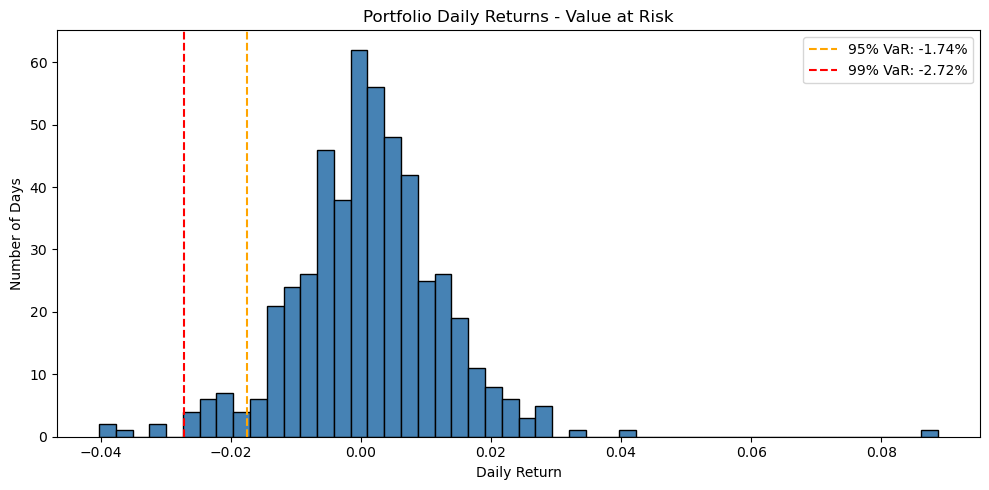

Chart Saved!


In [20]:
plt.figure(figsize=(10, 5))
plt.hist(portfolio_returns, bins=50, color='steelblue', edgecolor='black')
plt.axvline(VaR_95, color='orange', linestyle='--',
            label=f'95% VaR: {VaR_95:.2%}')
plt.axvline(VaR_99, color='red', linestyle='--',
            label=f'99% VaR: {VaR_99:.2%}')
plt.title('Portfolio Daily Returns - Value at Risk')
plt.xlabel('Daily Return')
plt.ylabel('Number of Days')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/market_risk_VaR.png')
plt.show()

print("Chart Saved!")

In [21]:
# Parameters from historical data
mean_return = portfolio_returns.mean()
std_return = portfolio_returns.std()
simulations = 10000

# Simulate 10,000 random days
simulated_returns = np.random.normal(mean_return, std_return, simulations)

# Calculute VaR from simulation
mc_VaR_95 = np.percentile(simulated_returns, 5)
mc_VaR_99 = np.percentile(simulated_returns, 1)

print(f"Monte Carlo VaR (95%): {mc_VaR_95:.2%}")
print(f"Monte Carlo VaR (99%): {mc_VaR_99:.2%}")
print()
print(f"On a $1,000,000 portfolio:")
print(f"95% VaR: ${mc_VaR_95 * portfolio_value:,.0f}")
print(f"99% VaR: ${mc_VaR_99 * portfolio_value:,.0f}")

Monte Carlo VaR (95%): -1.79%
Monte Carlo VaR (99%): -2.68%

On a $1,000,000 portfolio:
95% VaR: $-17,931
99% VaR: $-26,757


In [ ]:
plt.figure(figsize=(10,5))
plt.hist(simulated_returns, bins=100, color='purple',
         edgecolor='black', alpha=0.7)
plt.axvline(mc_VaR_95, color='orange', linestyle='--',
            label=f'95% VaR: {mc_VaR_95:.2%}')
plt.axvline(mc_VaR_99, color='red', linestyle='--',
            label=f'99% VaR: {mc_VaR_99:.2%}')
plt.title('Monte Carlo Simulation - 10,000 Scenarios')
plt.xlabel('Simulated Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig(../outputs.monte_carlo_VaR.png')
plt.show()

